## State Schema with Dataclasses

When we define LangGraph StateGraph, we use a state schema.

The state schema represents the structure and types of data that our graph will use.

All the Nodes are expected to communicate with that State schema.

LangGraph offers flexibility in how you define your state schema, accommodating various Python types and validation approaches.

In [2]:
from typing_extensions import TypedDict
from typing import Literal

class TypedDictState(TypedDict):
    name: str
    game: Literal['football', 'tennis']

In [5]:
def play_game(state: TypedDictState):
    print('-----Play_game has been called-----')
    return { 'name': state['name'], 'game': '' }

def football(state: TypedDictState):
    print('-----Football node has been called-----')
    return { 'name': state['name'], 'game': 'football' }

def tennis(state: TypedDictState):
    print('-----Tennis node has been called-----')
    return { 'name': state['name'], 'game': 'tennis' }

#### Building graph

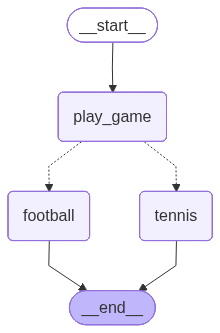

In [7]:
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

def random_play(state: TypedDictState) -> Literal["tennis", 'football']:
    if random.randint(0, 1) > .5:
        return 'football'
    return 'tennis' 

builder = StateGraph(TypedDictState)

# Nodes
builder.add_node('play_game', play_game)
builder.add_node('football', football)
builder.add_node('tennis', tennis)

# Edges
builder.add_edge(start_key=START, end_key='play_game')
builder.add_conditional_edges('play_game', random_play)
builder.add_edge(start_key='football', end_key=END)
builder.add_edge(start_key='football', end_key=END)

graph = builder.compile()

# Visualize
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
graph.invoke(input={
    'name': 'Dimo'
})

-----Play_game has been called-----
-----Football node has been called-----


{'name': 'Dimo', 'game': 'football'}

But when the State graph type is `TypedDict` it will not provide any validations of the input. 

For exmaple: Even that State.name is `str`, I can provide `int` and will still work

In [9]:
graph.invoke(input={
    'name': 1914
})

-----Play_game has been called-----
-----Football node has been called-----


{'name': 1914, 'game': 'football'}

### State with Dataclasses

Not only TypeDict can be State Graph class. We can also use Python's dataclasses.

Python **dataclasses** provide another way to define structured data. Dataclasses offer a concise syntax for creating classes that are primary used to store data. 

In [10]:
from dataclasses import dataclass


@dataclass
class DataclassState:
    name: str
    game: Literal['tennis', 'football']

In [11]:
def play_game(state: DataclassState):
    print('-----Play_game has been called-----')
    return { 'name': state.name, 'game': '' }

def football(state: DataclassState):
    print('-----Football node has been called-----')
    return { 'name': state.name, 'game': 'football' }

def tennis(state: DataclassState):
    print('-----Tennis node has been called-----')
    return { 'name': state.name, 'game': 'tennis' }

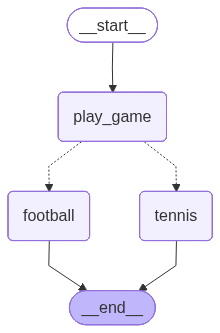

In [12]:
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

def random_play(state: DataclassState) -> Literal["tennis", 'football']:
    if random.randint(0, 1) > .5:
        return 'football'
    return 'tennis' 

builder = StateGraph(DataclassState)

# Nodes
builder.add_node('play_game', play_game)
builder.add_node('football', football)
builder.add_node('tennis', tennis)

# Edges
builder.add_edge(start_key=START, end_key='play_game')
builder.add_conditional_edges('play_game', random_play)
builder.add_edge(start_key='football', end_key=END)
builder.add_edge(start_key='football', end_key=END)

graph = builder.compile()

# Visualize
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
state = DataclassState(name='Dimo', game='tennis')
graph.invoke(input=state)

-----Play_game has been called-----
-----Football node has been called-----


{'name': 'Dimo', 'game': 'football'}